# Minimalny sanity check (COCO RLE)

## 1 — ścieżki i importy

In [1]:
import os, json, random
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt

from pycocotools.coco import COCO
from pycocotools import mask as mask_utils

DATASET_DIR = os.path.abspath("./data_coco")  # notebook jest w notebooks/
ANN = os.path.join(DATASET_DIR, "annotations", "instances_train.json")
IMG_DIR = os.path.join(DATASET_DIR, "images", "train")

print("ANN:", ANN)
print("IMG_DIR:", IMG_DIR)
print("Exists:", os.path.exists(ANN), os.path.exists(IMG_DIR))


ANN: c:\Users\VR.VR_ASUS\Documents\SynCity3D\jupyter\data_coco\annotations\instances_train.json
IMG_DIR: c:\Users\VR.VR_ASUS\Documents\SynCity3D\jupyter\data_coco\images\train
Exists: True True


## 2 — podstawowe statystyki i integralność

In [9]:
coco = COCO(ANN)

img_ids = coco.getImgIds()
cat_ids = coco.getCatIds()
cats = coco.loadCats(cat_ids)

print("Images:", len(img_ids))
print("Categories:", [(c["id"], c["name"]) for c in cats])

# Liczba adnotacji per klasa
for c in cats:
    ann_ids = coco.getAnnIds(catIds=[c["id"]])
    print(f"Annotations for {c['name']}: {len(ann_ids)}")

# Sprawdzenie: czy pliki obrazów istnieją
missing = 0
for i in random.sample(img_ids, min(50, len(img_ids))):
    f = coco.loadImgs([i])[0]["file_name"]
    if not os.path.exists(os.path.join(IMG_DIR, f)):
        missing += 1
print("Missing files in sample:", missing)


loading annotations into memory...
Done (t=0.02s)
creating index...
index created!
Images: 166
Categories: [(1, 'poprawny')]
Annotations for poprawny: 3779
Missing files in sample: 0


## 3 — wizualizacja losowych przykładów (RLE → mask overlay)

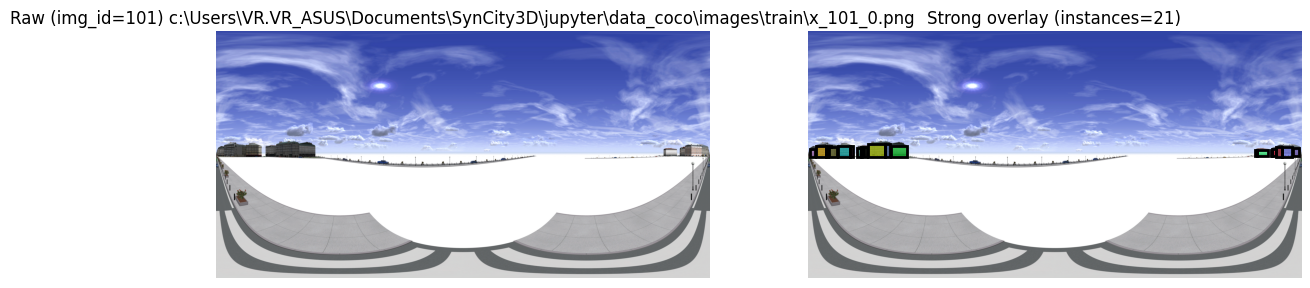

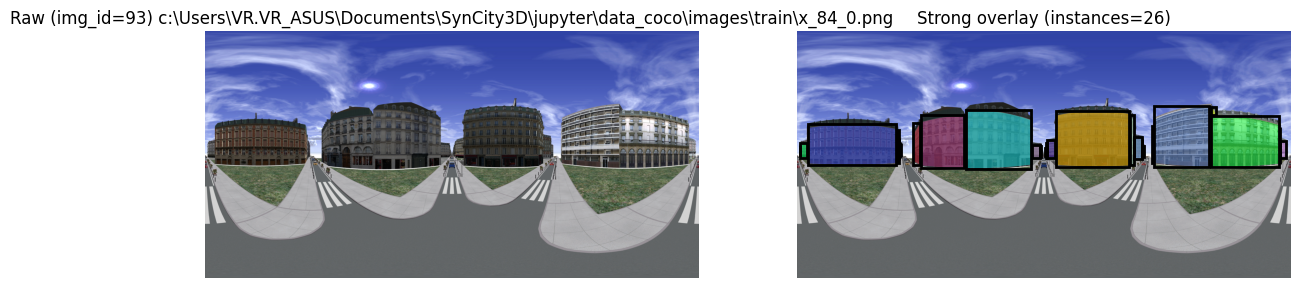

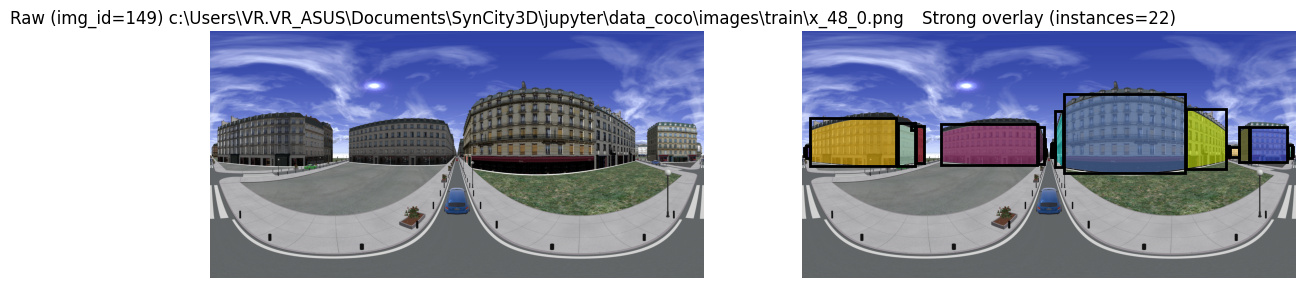

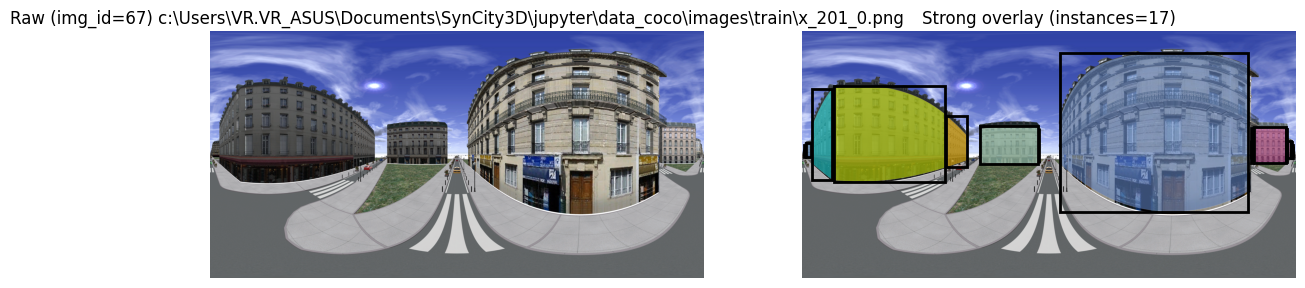

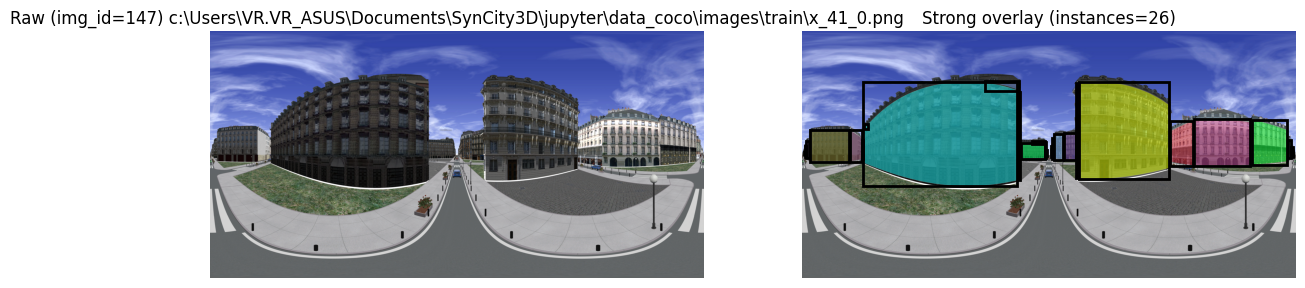

In [10]:
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
import random, os

from pycocotools import mask as mask_utils

def draw_bbox(ax, bbox, linewidth=2):
    x, y, w, h = bbox
    rect = plt.Rectangle((x, y), w, h, fill=False, linewidth=linewidth)
    ax.add_patch(rect)

def overlay_strong(img, anns, alpha=0.6, max_inst=80, show_bboxes=True, show_contours=True):
    """
    img: HxWx3 uint8
    anns: list of COCO annotations for a single image
    """
    H, W = img.shape[:2]
    overlay = img.astype(np.float32).copy()

    # losowe kolory per instancja (deterministycznie dla powtarzalności)
    rng = np.random.default_rng(0)

    for i, a in enumerate(anns[:max_inst]):
        m = mask_utils.decode(a["segmentation"]).astype(bool)
        if m.shape[0] != H or m.shape[1] != W:
            continue

        color = rng.integers(low=0, high=256, size=3, dtype=np.uint8).astype(np.float32)

        # mocna półprzezroczysta warstwa
        overlay[m] = (1 - alpha) * overlay[m] + alpha * color

        # kontur (1px) – bardzo pomaga
        if show_contours:
            # kontur jako brzeg: piksele maski które mają sąsiada poza maską
            # (proste i szybkie, bez skimage)
            mm = m
            up    = np.zeros_like(mm); up[1:,:] = mm[:-1,:]
            down  = np.zeros_like(mm); down[:-1,:] = mm[1:,:]
            left  = np.zeros_like(mm); left[:,1:] = mm[:,:-1]
            right = np.zeros_like(mm); right[:,:-1] = mm[:,1:]
            edge = mm & ~(up & down & left & right)

            overlay[edge] = 255  # biały kontur

        if show_bboxes:
            # bbox z JSON
            pass

    out = np.clip(overlay, 0, 255).astype(np.uint8)
    return out

def show_random_strong(n=5, max_inst=80, show_bboxes=True):
    for _ in range(n):
        img_id = random.choice(img_ids)
        img_info = coco.loadImgs([img_id])[0]
        path = os.path.join(IMG_DIR, img_info["file_name"])
        img = np.array(Image.open(path).convert("RGB"))

        ann_ids = coco.getAnnIds(imgIds=[img_id])
        anns = coco.loadAnns(ann_ids)

        fig = plt.figure(figsize=(14,6))
        ax1 = plt.subplot(1,2,1)
        ax1.set_title(f"Raw (img_id={img_id}) {path}")
        ax1.imshow(img)
        ax1.axis("off")

        ax2 = plt.subplot(1,2,2)
        ax2.set_title(f"Strong overlay (instances={len(anns)})")
        out = overlay_strong(img, anns, alpha=0.6, max_inst=max_inst, show_bboxes=show_bboxes, show_contours=True)
        ax2.imshow(out)
        ax2.axis("off")

        # bboxy rysujemy dopiero po imshow (na ax2), żeby były na wierzchu
        if show_bboxes:
            for a in anns[:max_inst]:
                draw_bbox(ax2, a["bbox"], linewidth=2)

        plt.show()

show_random_strong(n=5, max_inst=60, show_bboxes=True)


## 4 — twardy sanity: zgodność area/bbox z maską (próbka)

In [2]:
def check_sample(k=200):
    bad_area = 0
    bad_bbox = 0

    ann_ids = coco.getAnnIds()
    sample = random.sample(ann_ids, min(k, len(ann_ids)))

    for aid in sample:
        a = coco.loadAnns([aid])[0]
        rle = a["segmentation"]
        area_api = float(mask_utils.area(rle))
        bbox_api = mask_utils.toBbox(rle).tolist()

        # porównaj z zapisanym w JSON
        area_json = float(a["area"])
        bbox_json = [float(x) for x in a["bbox"]]

        if abs(area_api - area_json) > 1e-3:
            bad_area += 1

        # bbox bywa float — porównuj tolerancyjnie
        if any(abs(bbox_api[i] - bbox_json[i]) > 1e-3 for i in range(4)):
            bad_bbox += 1

    print("Checked:", len(sample))
    print("Area mismatches:", bad_area)
    print("BBox mismatches:", bad_bbox)

check_sample(300)


NameError: name 'coco' is not defined